In [1]:
import numpy as np
import polars as pl

from lmpy import lme, gam
from lmpy.data import data
from lmpy.compare import anova, AIC, BIC

### 2.5.4 + 2.5.5

In [2]:
Machines = data("Machines", "nlme")
Machines

Worker,Machine,score
enum,enum,f64
"""1""","""A""",52.0
"""1""","""A""",52.8
"""1""","""A""",53.1
"""2""","""A""",51.8
"""2""","""A""",52.8
…,…,…
"""5""","""C""",72.0
"""5""","""C""",71.1
"""6""","""C""",62.0


In [3]:

a1 = lme('score ~ Machine + (1|Worker) + (1|Worker:Machine)', data=Machines)
a2 = lme('score ~ Machine + (1|Worker) + (Machine-1|Worker)', data=Machines)
AIC(a1,a2)


    df     AIC
a1   6  227.69
a2  11  230.31


In [4]:
anova(a1, a2)

refitting model(s) with ML (instead of REML)
Analysis of Variance Table (likelihood ratio test)

a1: score ~ Machine + (1|Worker) + (1|Worker:Machine)
a2: score ~ Machine + (1|Worker) + (Machine-1|Worker)

    npar       AIC       BIC     logLik  deviance   Chisq  Df  Pr(>Chisq)
a1     6  237.2695  249.2034  -112.6347  225.2695
a2    11  238.4185  260.2973  -108.2093  216.4185  8.8509   5      0.1152
---
Signif. codes: 0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1


In [5]:
b1 = gam('score ~ Machine + s(Worker, bs="re") + s(Machine, Worker, bs="re")', data=Machines, method='REML')
b1.vcomp


name,std_dev,lower,upper
str,f64,f64,f64
"""s(Worker)""",4.781051,2.249858,10.15995
"""s(Machine,Worker)""",3.729538,2.382816,5.837404
"""scale""",0.961577,0.763254,1.211432


In [6]:
b2 = gam('score ~ Machine + s(Worker,bs="re") + s(Worker,bs="re",by=Machine)',data=Machines, method='REML')
b2.vcomp

name,std_dev,lower,upper
str,f64,f64,f64
"""s(Worker)""",3.785947,1.798732,7.968613
"""s(Worker):MachineA""",1.940322,0.253188,14.869794
"""s(Worker):MachineB""",5.874023,2.988334,11.546281
"""s(Worker):MachineC""",2.84547,0.829933,9.75585
"""scale""",0.961577,0.763254,1.211432


In [7]:
AIC(b1, b2)

           df     AIC
b1  18.859954  165.19
b2  18.985573  165.62


### 4.6

In [8]:
trees = data("trees", "mgcv")

In [9]:
from lmpy.family import Gamma
ct1 = gam('Volume ~ s(Height) + s(Girth)', family=Gamma(link="log"), data=trees)
ct1.summary()


Family: Gamma
Link function: log

Formula: Volume ~ s(Height) + s(Girth)

Parametric coefficients:
             Estimate  Std. Error  t value  Pr(>|t|)
(Intercept)   3.27570     0.01492    219.6    <2e-16  ***
---
Signif. codes: 0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

Approximate significance of smooth terms:
             edf  Ref.df       F   p-value
s(Height)  1.000   1.000   31.32  6.51e-06  ***
s(Girth)   2.422   3.044  219.28   < 2e-16  ***
---
Signif. codes: 0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

R-sq.(adj) = 0.973  Deviance explained = 97.8%
GCV = 0.0080824  Scale est. = 0.006899  n = 31


### 7.2

In [10]:
brain = data("brain", "gamair")
brain = brain.filter(pl.col("medFPQ") > 5e-3)

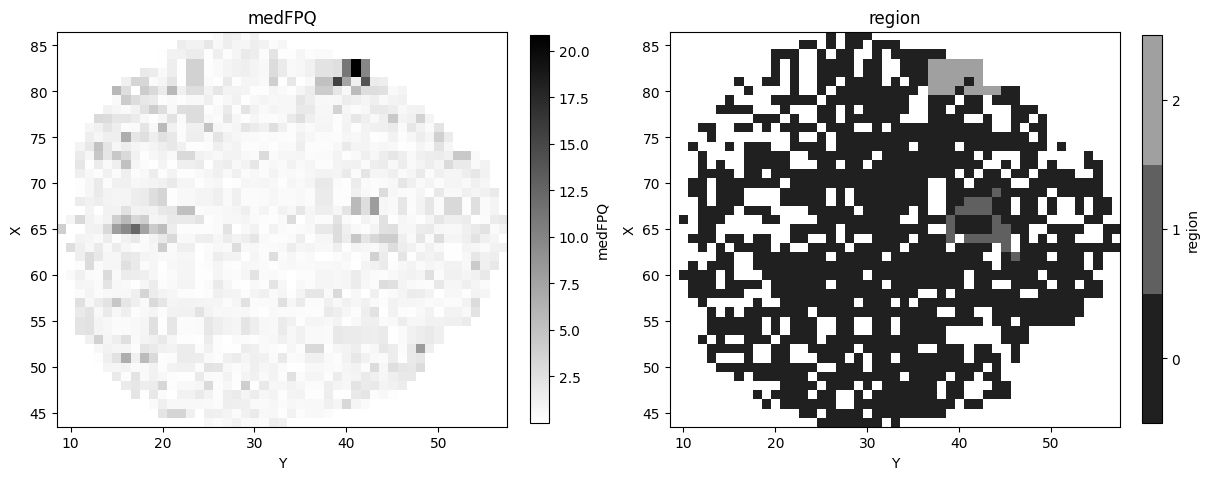

In [11]:
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

X_min, X_max = brain["X"].min(), brain["X"].max()
Y_min, Y_max = brain["Y"].min(), brain["Y"].max()
nx = X_max - X_min + 1
ny = Y_max - Y_min + 1

medFPQ = np.full((nx, ny), np.nan)   # rows=X, cols=Y
region = np.full((nx, ny), np.nan)
for row in brain.iter_rows(named=True):
    i = row["X"] - X_min   # row index = X
    j = row["Y"] - Y_min   # col index = Y
    medFPQ[i, j] = row["medFPQ"]
    if row["region"] is not None:
        region[i, j] = row["region"]

extent = (Y_min - 0.5, Y_max + 0.5, X_min - 0.5, X_max + 0.5)  # (left, right, bottom, top)

fig, axes = plt.subplots(1, 2, figsize=(12, 5), constrained_layout=True)

im0 = axes[0].imshow(medFPQ, origin="lower", cmap="gray_r",
                     aspect="equal", extent=extent)
fig.colorbar(im0, ax=axes[0], label="medFPQ", shrink=0.8)
axes[0].set(xlabel="Y", ylabel="X", title="medFPQ")

cmap_reg = ListedColormap(["#202020", "#606060", "#A0A0A0"])
im1 = axes[1].imshow(region, origin="lower", cmap=cmap_reg,
                     aspect="equal", vmin=-0.5, vmax=2.5, extent=extent)
fig.colorbar(im1, ax=axes[1], ticks=[0, 1, 2],
             label="region", shrink=0.8)
axes[1].set(xlabel="Y", ylabel="X", title="region")
plt.show()

In [12]:
m0 = gam('medFPQ ~ s(Y, X, k=100)', data=brain)
m1 = gam('medFPQ^.25 ~ s(Y, X, k=100)', data=brain)
m2 = gam('medFPQ ~ s(Y, X, k=100)', data=brain, family=Gamma(link="log"))
m3 = gam('medFPQ ~ s(Y,k=30) + s(X,k=30)', data=brain, family=Gamma(link="log"))

tm = gam('medFPQ ~ te(Y, X, k=10)', data=brain, family=Gamma(link="log"))

# (d) main effects + interaction, estimated separately
tm1 = gam('medFPQ ~ s(Y, k=10, bs="cr") + s(X, k=10, bs="cr") + ti(Y, X, k=10)',
          data=brain, family=Gamma(link="log"))

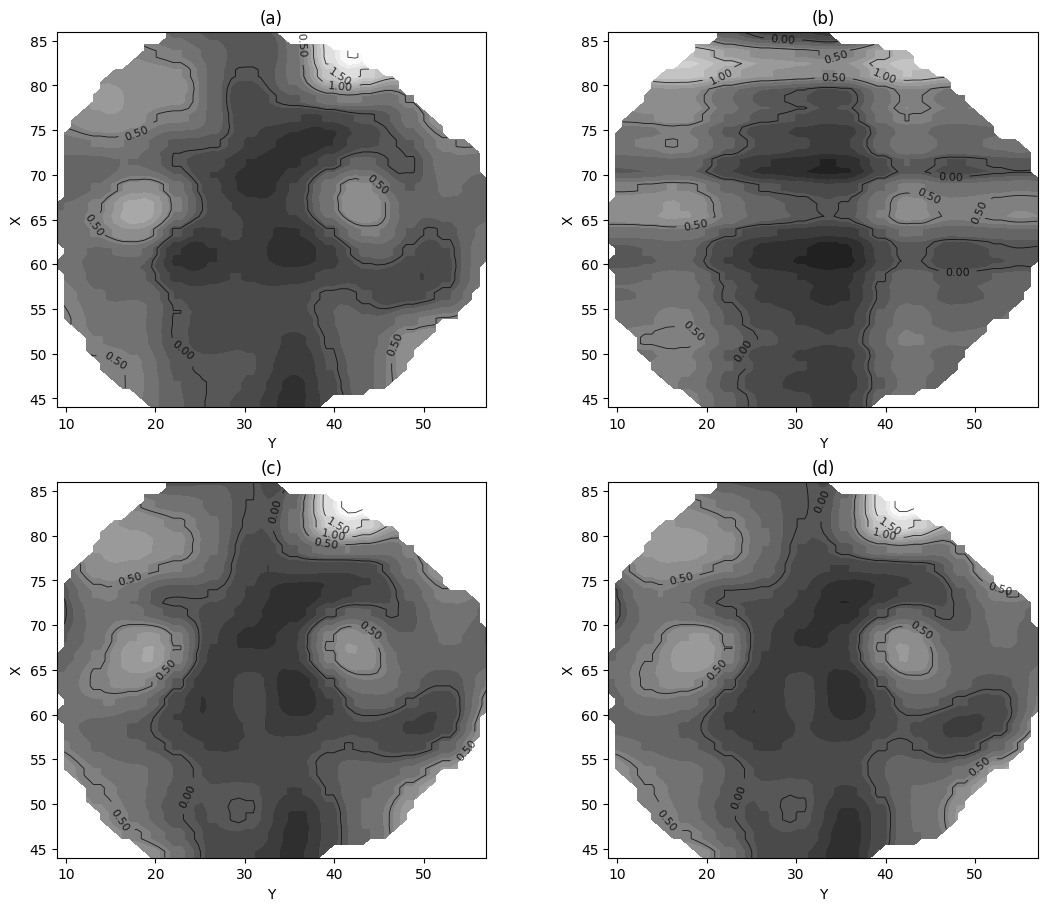

In [16]:
fig, axes = plt.subplot_mosaic(
    [["a", "b"],
     ["c", "d"]],
    figsize=(11, 9),
    constrained_layout=True,
)
for label, m in zip("abcd", [m2, m3, tm, tm1]):
    m.vis(view=("Y", "X"), too_far=0.03, n_grid=60).plot(
        kind="contour",
        ax=axes[label],
        cmap="gray",
        levels=np.linspace(-1, 2, 20),
        contour_levels=np.linspace(0, 2, 5),
        colorbar=False,
        clabel=True,
    )
    axes[label].set_title(f"({label})")
plt.show()